In [25]:
from qdrant_client import QdrantClient
from qdrant_client.http.models import Filter, FieldCondition, MatchValue
from qdrant_client.models import Distance, VectorParams, PointStruct
from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csgraph
from sklearn.manifold import SpectralEmbedding
from sklearn.preprocessing import normalize

import numpy as np
import torch
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import re

#importing the used models
from transformers import BlipProcessor, BlipModel

from utils.metrics import iterate_ds, mean_reciprocal_rank, recall_at_k

In [64]:
def load_and_filter_data(caption_csv_path):
    img_dir="./images"
    img_prefix="img_"
    df = pd.read_csv(caption_csv_path, encoding='latin1')
    df['image_filename'] = [f"{img_prefix}{i}.jpg" for i in df.index]
    df['full_image_path'] = [f"{img_dir}/{fname}" for fname in df['image_filename']]
    df_valid = df[df['full_image_path'].apply(os.path.exists)].reset_index(drop=True)
    print(f"Valid images with captions: {len(df_valid)}")
    return df_valid


def generate_image_embeddings(image_paths, processor, model, device):
    embeddings = []
    for path in image_paths:
        try:
            image = Image.open(path).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(device)
            with torch.no_grad():
                features = model.get_image_features(**inputs)
            features = features / features.norm(p=2, dim=-1, keepdim=True)
            embeddings.append(features.cpu().numpy().squeeze())
        except Exception as e:
            print(f"Error processing image {path}: {e}")
    return np.array(embeddings)

def generate_text_embeddings(texts, processor, model, device):
    embeddings = []
    for text in texts:
        try:
            inputs = processor(text=text, return_tensors="pt").to(device)
            with torch.no_grad():
                features = model.get_text_features(**inputs)
            features = features / features.norm(p=2, dim=-1, keepdim=True)
            embeddings.append(features.cpu().numpy().squeeze())
        except Exception as e:
            print(f"Error processing text '{text[:30]}...': {e}")
    return np.array(embeddings)

def match_embeddings(image_embeddings, text_embeddings, valid_image_paths, valid_captions):
    similarity_matrix = cosine_similarity(image_embeddings, text_embeddings)
    print(similarity_matrix)
    matched_pairs = []
    for i in range(similarity_matrix.shape[0]):
        j = np.argmax(similarity_matrix[i])
        matched_pairs.append({
            "image_path": valid_image_paths[i],
            "caption": valid_captions[j],
            "image_embedding": image_embeddings[i],
            "text_embedding": text_embeddings[j],
            "similarity": similarity_matrix[i, j]
        })
    print(f"Matched {len(matched_pairs)} image-caption pairs via cosine similarity.")
    return matched_pairs, similarity_matrix

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipModel.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

df_long = load_and_filter_data("./long_generated_captions.csv")
df_short = load_and_filter_data("./short_generated_captions.csv")

valid_image_paths = df_long['full_image_path'].tolist()
valid_captions_long = df_long['paraphrased_caption'].tolist()
valid_captions_short = df_short['paraphrased_caption'].tolist()

image_embeddings = generate_image_embeddings(valid_image_paths, processor, model, device)
text_embeddings_long = generate_text_embeddings(valid_captions_long, processor, model, device)
text_embeddings_short = generate_text_embeddings(valid_captions_short, processor, model, device)
matched_pairs_long, similarity_matrix_spectral_long = match_embeddings(image_embeddings, text_embeddings_long, valid_image_paths, valid_captions_long)
matched_pairs_short, similarity_matrix_spectral_short = match_embeddings(image_embeddings, text_embeddings_short, valid_image_paths, valid_captions_short)

`BlipModel` is going to be deprecated in future release, please use `BlipForConditionalGeneration`, `BlipForQuestionAnswering` or `BlipForImageTextRetrieval` depending on your usecase.
Some weights of BlipModel were not initialized from the model checkpoint at Salesforce/blip-image-captioning-base and are newly initialized: ['logit_scale', 'text_model.embeddings.LayerNorm.bias', 'text_model.embeddings.LayerNorm.weight', 'text_model.embeddings.position_embeddings.weight', 'text_model.embeddings.word_embeddings.weight', 'text_model.encoder.layer.0.attention.output.LayerNorm.bias', 'text_model.encoder.layer.0.attention.output.LayerNorm.weight', 'text_model.encoder.layer.0.attention.output.dense.bias', 'text_model.encoder.layer.0.attention.output.dense.weight', 'text_model.encoder.layer.0.attention.self.key.bias', 'text_model.encoder.layer.0.attention.self.key.weight', 'text_model.encoder.layer.0.attention.self.query.bias', 'text_model.encoder.layer.0.attention.self.query.weight', 'text_mo

Valid images with captions: 499
Valid images with captions: 423


KeyboardInterrupt: 

In [65]:
def apply_spectral_embedding_from_cosine(B, n_components=128):
    B = np.clip(B, 0, None)

    n_texts, n_images = B.shape

    zero_text = np.zeros((n_texts, n_texts))
    zero_image = np.zeros((n_images, n_images))
    
    A = np.block([
        [zero_text, B],
        [B.T, zero_image]
    ])

    epsilon = 1e-3
    A += epsilon
    np.fill_diagonal(A, epsilon)

    n_total = A.shape[0]
    if n_components >= n_total:
        n_components = n_total - 1
        print(f"Warning: n_components reduced to {n_components} because it must be less than total nodes {n_total}")

    spectral = SpectralEmbedding(n_components=n_components, affinity='precomputed')
    embedded = spectral.fit_transform(A)

    spectral_text = normalize(embedded[:n_texts])
    spectral_image = normalize(embedded[n_texts:])
    
    return spectral_image, spectral_text


In [ ]:
spectral_image_embeddings, spectral_text_long_embeddings = apply_spectral_embedding_from_cosine(similarity_matrix_spectral_long)
spectral_image_embeddings, spectral_text_short_embeddings = apply_spectral_embedding_from_cosine(similarity_matrix_spectral_short)

## Generate and add vector embeddings to Qdrant
**Normal embeddings of original_captions column**

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipModel.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

df_valid = load_and_filter_data("./pixel_prose.csv")

`BlipModel` is going to be deprecated in future release, please use `BlipForConditionalGeneration`, `BlipForQuestionAnswering` or `BlipForImageTextRetrieval` depending on your usecase.
Some weights of BlipModel were not initialized from the model checkpoint at Salesforce/blip-image-captioning-base and are newly initialized: ['logit_scale', 'text_model.embeddings.LayerNorm.bias', 'text_model.embeddings.LayerNorm.weight', 'text_model.embeddings.position_embeddings.weight', 'text_model.embeddings.word_embeddings.weight', 'text_model.encoder.layer.0.attention.output.LayerNorm.bias', 'text_model.encoder.layer.0.attention.output.LayerNorm.weight', 'text_model.encoder.layer.0.attention.output.dense.bias', 'text_model.encoder.layer.0.attention.output.dense.weight', 'text_model.encoder.layer.0.attention.self.key.bias', 'text_model.encoder.layer.0.attention.self.key.weight', 'text_model.encoder.layer.0.attention.self.query.bias', 'text_model.encoder.layer.0.attention.self.query.weight', 'text_mo

Valid images with captions: 423


In [36]:
df_valid = df_valid.rename(columns={'Unnamed: 0': "img_idx"})

### Add to Qdrant

In [ ]:
df_s_captions = pd.read_csv("./short_generated_captions.csv", encoding='latin1') 

In [ ]:
valid_captions = df_s_captions['original_caption'].tolist()
# img_ids = df_s_captions["id"].tolist()
# needed as our dataset saved from 1 and not 0
# valid_img_idx = [id+1 for id in img_ids]
directory = Path("./images/")
ids = [int(re.search(r"(\d+)", f.name).group()) for f in directory.iterdir()]
# 
ids = sorted(ids)
print(ids)

valid_img_paths = [f'./images/img_{id}.jpg' for id in ids]

image_embeddings = generate_image_embeddings(valid_img_paths, processor, model, device)
text_embeddings = generate_text_embeddings(valid_captions, processor, model, device)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 57, 58, 59, 60, 62, 63, 64, 65, 66, 67, 68, 69, 71, 72, 73, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 115, 116, 117, 118, 120, 121, 122, 124, 125, 127, 128, 129, 130, 131, 133, 134, 135, 136, 137, 139, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 153, 155, 156, 157, 158, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 216, 217, 218, 220, 222, 223, 224, 225, 227, 230, 231, 232, 234, 235, 236, 238, 239, 240, 241, 242, 243, 244, 245, 247, 249, 250, 251, 252, 254, 255, 

In [104]:
image_embeddings = generate_image_embeddings(valid_img_paths, processor, model, device)
# text_embeddings = generate_text_embeddings(valid_captions, processor, model, device)

In [105]:
image_embeddings[0]

array([-7.70121664e-02,  5.92717901e-02,  9.24688727e-02, -4.37390059e-02,
       -6.24608155e-03,  5.57121402e-03,  1.26642026e-02, -7.07347766e-02,
        2.14814860e-02,  6.06803410e-02, -4.37984690e-02,  4.05192748e-02,
       -2.49339659e-02,  4.48447019e-02,  2.40776930e-02,  6.36092350e-02,
       -2.97167897e-02,  2.23225672e-02, -5.65723283e-03,  2.02166867e-02,
        5.53817898e-02, -1.07493751e-01,  2.73908861e-02, -5.27944788e-02,
        1.26250265e-02,  8.10338464e-03,  1.52123894e-03,  3.14783044e-02,
       -3.73760723e-02, -9.67869628e-03,  2.18797345e-02, -4.82607931e-02,
       -5.64181954e-02,  4.50608470e-02,  4.32060519e-03, -4.94924486e-02,
        5.75426333e-02,  2.32763421e-02, -2.19364725e-02,  6.14153408e-02,
       -2.07611639e-03, -1.30978515e-02, -4.57523949e-03, -1.98636930e-02,
        2.18555294e-02,  2.40907669e-02, -3.24968547e-02, -1.57917328e-02,
       -7.15840794e-03,  6.88815936e-02, -5.04222922e-02,  6.64489493e-02,
        5.14629893e-02,  

In [67]:
len(text_embeddings) == len(image_embeddings)

True

In [109]:
collection_name = "normal_original_captions"

client = QdrantClient(host="localhost", port=6333)

points = [
    PointStruct(id=idx, vector=vec, payload={})
    for idx, vec in zip(ids, image_embeddings)
]

client.upsert(collection_name=collection_name, points=points)

UpdateResult(operation_id=6, status=<UpdateStatus.COMPLETED: 'completed'>)

In [116]:
point = [
    PointStruct(id=90945862, vector=image_embeddings[0], payload={})
]

client.upsert(collection_name=collection_name, points=point)

UpdateResult(operation_id=8, status=<UpdateStatus.COMPLETED: 'completed'>)

In [119]:
# result = client.retrieve(
#             collection_name=collection_name,
#             ids=[ids],
#             with_payload=False
#         )

result = client.retrieve(collection_name=collection_name, ids=[90945862], with_vectors=True)

In [123]:
result[0].vector

[-0.07701217,
 0.05927179,
 0.09246887,
 -0.043739006,
 -0.0062460816,
 0.005571214,
 0.012664203,
 -0.07073478,
 0.021481486,
 0.06068034,
 -0.04379847,
 0.040519275,
 -0.024933966,
 0.044844702,
 0.024077693,
 0.063609235,
 -0.02971679,
 0.022322567,
 -0.005657233,
 0.020216687,
 0.05538179,
 -0.10749375,
 0.027390886,
 -0.05279448,
 0.0126250265,
 0.008103385,
 0.0015212389,
 0.031478304,
 -0.037376072,
 -0.009678696,
 0.021879734,
 -0.048260793,
 -0.056418195,
 0.045060847,
 0.004320605,
 -0.04949245,
 0.057542633,
 0.023276342,
 -0.021936473,
 0.06141534,
 -0.0020761164,
 -0.013097852,
 -0.0045752395,
 -0.019863693,
 0.02185553,
 0.024090767,
 -0.032496855,
 -0.015791733,
 -0.007158408,
 0.06888159,
 -0.050422292,
 0.06644895,
 0.05146299,
 0.048716556,
 0.04550117,
 0.014172572,
 0.055065144,
 0.02224375,
 0.018503731,
 0.0051861014,
 0.017742766,
 0.0525006,
 -0.08102487,
 0.0095326025,
 -0.027933113,
 -0.053809643,
 -0.07543016,
 0.010492748,
 -0.008310084,
 0.038146842,
 -0.03

In [69]:
client = QdrantClient(url="http://localhost:6333")

df_short = pd.read_csv("./short_generated_captions.csv", encoding='latin1')
df_long = pd.read_csv("./long_generated_captions.csv", encoding='latin1')

device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipModel.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

datasets = [("Short Captions", df_short), ("Long Captions", df_long)]
metrics = ["mrr", "recall@k"]

for name, df in datasets:
    for metric in metrics:
        avg_score = iterate_ds(3, df, metric, processor, model, "paraphrased_caption", client, "normal_original_captions", device)
        print(f"Average {metric.upper()} for {name}: {avg_score:.4f}")

`BlipModel` is going to be deprecated in future release, please use `BlipForConditionalGeneration`, `BlipForQuestionAnswering` or `BlipForImageTextRetrieval` depending on your usecase.
Some weights of BlipModel were not initialized from the model checkpoint at Salesforce/blip-image-captioning-base and are newly initialized: ['logit_scale', 'text_model.embeddings.LayerNorm.bias', 'text_model.embeddings.LayerNorm.weight', 'text_model.embeddings.position_embeddings.weight', 'text_model.embeddings.word_embeddings.weight', 'text_model.encoder.layer.0.attention.output.LayerNorm.bias', 'text_model.encoder.layer.0.attention.output.LayerNorm.weight', 'text_model.encoder.layer.0.attention.output.dense.bias', 'text_model.encoder.layer.0.attention.output.dense.weight', 'text_model.encoder.layer.0.attention.self.key.bias', 'text_model.encoder.layer.0.attention.self.key.weight', 'text_model.encoder.layer.0.attention.self.query.bias', 'text_model.encoder.layer.0.attention.self.query.weight', 'text_mo

Average MRR for Short Captions: 0.0030
Average RECALL@K for Short Captions: 0.0060
Average MRR for Long Captions: 0.0047
Average RECALL@K for Long Captions: 0.0080


In [124]:
def get_image_embeddings_from_qdrant(client: QdrantClient, collection_name: str, ids: list[int], dim=512):
    image_embeddings = []
    for idx in tqdm(ids, desc="Retrieving image embeddings"):
        result = client.retrieve(
            collection_name=collection_name,
            ids=[idx],
            with_vectors=True
        )
        if result and result[0].vector is not None:
            image_embeddings.append(result[0].vector)
        else:
            image_embeddings.append(np.zeros(dim))
    return np.array(image_embeddings)


In [125]:
def get_text_embeddings(df: pd.DataFrame, processor, model, device: str, caption_column: str):
    text_embeddings = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Computing text embeddings"):
        caption = row[caption_column]
        inputs = processor(text=caption, return_tensors="pt").to(device)
        with torch.no_grad():
            features = model.get_text_features(**inputs)
        features = features / features.norm(p=2, dim=-1, keepdim=True)
        text_embeddings.append(features.cpu().numpy().squeeze())
    return np.array(text_embeddings)

In [126]:
def mean_reciprocal_rank_spectral(k, spectral_text, spectral_image):
    sim = cosine_similarity(spectral_text, spectral_image)
    total = 0
    for idx in range(sim.shape[0]):
        top_k = np.argsort(sim[idx])[::-1]
        if idx in top_k[:k]:
            rank = np.where(top_k == idx)[0][0] + 1
            total += 1 / rank
    return total / sim.shape[0]

In [127]:
def recall_at_k_spectral(k, spectral_text, spectral_image):
    sim = cosine_similarity(spectral_text, spectral_image)
    total = 0
    for idx in range(sim.shape[0]):
        top_k = np.argsort(sim[idx])[-k:][::-1]
        if idx in top_k:
            total += 1
    return total / sim.shape[0]

In [128]:
client = QdrantClient(host="localhost", port=6333)

for name, df in [("Short", df_short), ("Long", df_long)]:
        print(f"\nProcessing {name} Captions")
        ids = df["id"]

        image_embeddings = get_image_embeddings_from_qdrant(client, collection_name, ids, dim=512)
        text_embeddings = get_text_embeddings(df, processor, model, device, "paraphrased_caption")

        B = cosine_similarity(text_embeddings, image_embeddings)

        spectral_text, spectral_image = apply_spectral_embedding_from_cosine(B, n_components=128)

        k = 3
        mrr = mean_reciprocal_rank_spectral(k, spectral_text, spectral_image)
        recall = recall_at_k_spectral(k, spectral_text, spectral_image)

        print(f"  Spectral MRR:      {mrr:.4f}")
        print(f"  Spectral Recall@{k}: {recall:.4f}")


Processing Short Captions


Computing text embeddings: 100%|██████████| 499/499 [00:24<00:00, 20.44it/s]


  Spectral MRR:      0.0020
  Spectral Recall@3: 0.0020

Processing Long Captions


Computing text embeddings: 100%|██████████| 499/499 [00:26<00:00, 18.82it/s]


  Spectral MRR:      0.0033
  Spectral Recall@3: 0.0060


In [130]:
image_embeddings = get_image_embeddings_from_qdrant(client, collection_name, ids, dim=512)
text_embeddings = get_text_embeddings(df, processor, model, device, "paraphrased_caption")

Computing text embeddings: 100%|██████████| 499/499 [00:25<00:00, 19.45it/s]


In [131]:
from sklearn.metrics.pairwise import cosine_distances

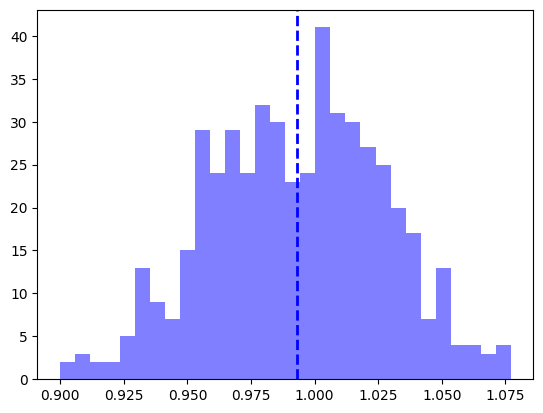

In [ ]:
# Create metrics for graphing 

distance = cosine_distances
distances = distance(image_embeddings, text_embeddings)
gt_distances = np.diag(distances)
global_mean = np.mean(distances)
plt.hist(gt_distances, bins=30, alpha=0.5, label="original embeddings", color='blue')
plt.axvline(global_mean, color='blue', linestyle='dashed', linewidth=2,
        label=f'mean text-image distance')